In [29]:
import os

data_dir = '/mnt/pixel_aid_disk1/projects/CCRR/data'
dst      = '/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel'

print("data_dir :", data_dir)
print("ccri_pixel:", dst)

data_dir : /mnt/pixel_aid_disk1/projects/CCRR/data
ccri_pixel: /mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel


In [30]:
import os

files_to_remove = [
    os.path.join(dst, 'air_pollution_pm25_1998-2023.tif'),
    os.path.join(dst, 'vectorborne_malariapf_2012-2022.tif'),
    os.path.join(dst, 'vectorborne_malariapv_2012-2022.tif'),
]

for file_path in files_to_remove:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Removed: {file_path}")
    else:
        print(f"Not found (skipping): {file_path}")

Not found (skipping): /mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/air_pollution_pm25_1998-2023.tif
Not found (skipping): /mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/vectorborne_malariapf_2012-2022.tif
Not found (skipping): /mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/vectorborne_malariapv_2012-2022.tif


In [31]:
import os
import glob
import numpy as np
import rasterio
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import normaltest, probplot
from scipy.stats import skew, kurtosis
import pandas as pd
from sklearn.decomposition import PCA

data_dir = '/mnt/pixel_aid_disk1/projects/CCRR/data'
dst      = '/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel'

In [32]:
# Define image folder and files
image_folder = dst
image_files = glob.glob(os.path.join(image_folder, "*.tif"))

# Load land-sea mask (1 = land, 0 = sea)
mask_path = os.path.join(image_folder, "landSeaMask.tif")
with rasterio.open(mask_path) as mask_src:
    landsea_mask = mask_src.read(1)  # Assuming single-band mask
    land_mask = landsea_mask == 1  # Boolean mask for land pixels

# Helper function to load images
def load_image(image_file):
    with rasterio.open(os.path.join(image_folder, image_file)) as src:
        data = src.read(1)  # Read the first band
        valid_data = np.where(land_mask, data, 0)  # Mask out sea area
        valid_data = np.nan_to_num(valid_data)  # Convert NaNs to zero
        return valid_data

# Load images and apply log transformation and z-score scaling
scaler = StandardScaler()

#function to trim outliers and return trimmed value and min and max values
def trim_outliers_iteratively(values, max_skew=2, max_kurtosis=3.5):
    """
    Iteratively removes extreme min/max values until skewness <= 2 and kurtosis <= 3.5.
    Returns the trimmed dataset along with the final min and max.
    """
    values_tmp = values.copy()  # Ensure no NaNs
    while True:
        current_skew = skew(values_tmp)
        current_kurtosis = kurtosis(values_tmp)

        if abs(current_skew) <= max_skew and current_kurtosis <= max_kurtosis:
            break  # Stop if conditions are met

        # Remove min and max values
        min_val, max_val = values_tmp.min(), values_tmp.max()
        values_tmp = values_tmp[(values_tmp > min_val) & (values_tmp < max_val)]  # Trim extreme min/max

    values = np.clip(values, values_tmp.min(), values_tmp.max())
    return values, values.min(), values.max()




/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/fire_FRP_nasa_2001-2024.tif: Log Transformation and z-score Scaling - skew=0.429, kurtosis=0.572


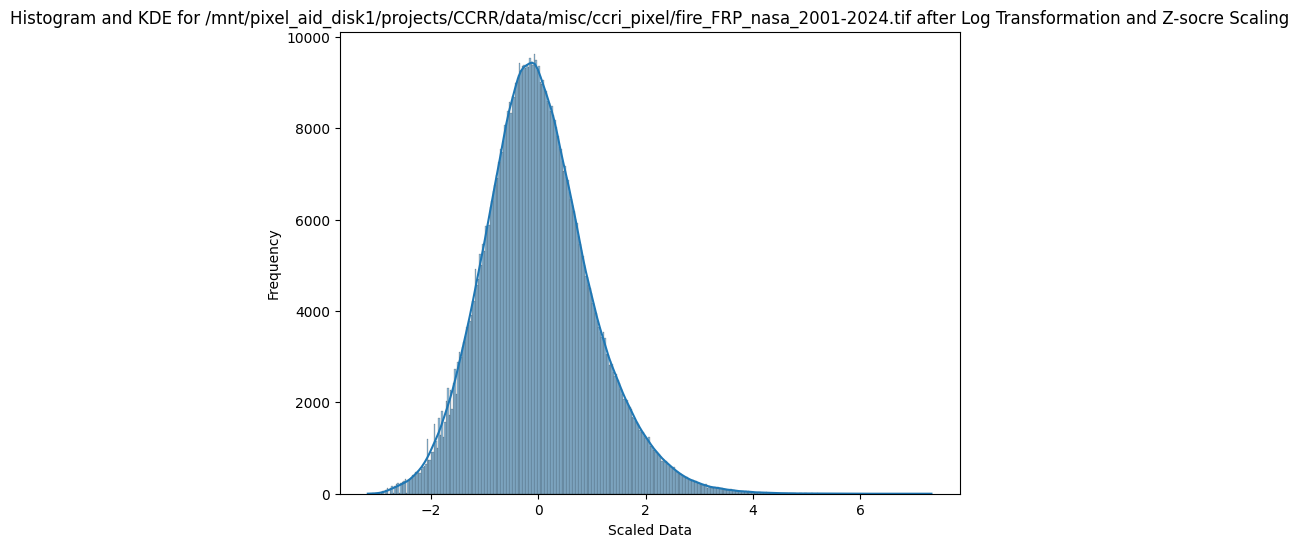

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/coastal_flood_100yr_jrc_2024.tif: Log Transformation and z-score Scaling - skew=1.512, kurtosis=0.886


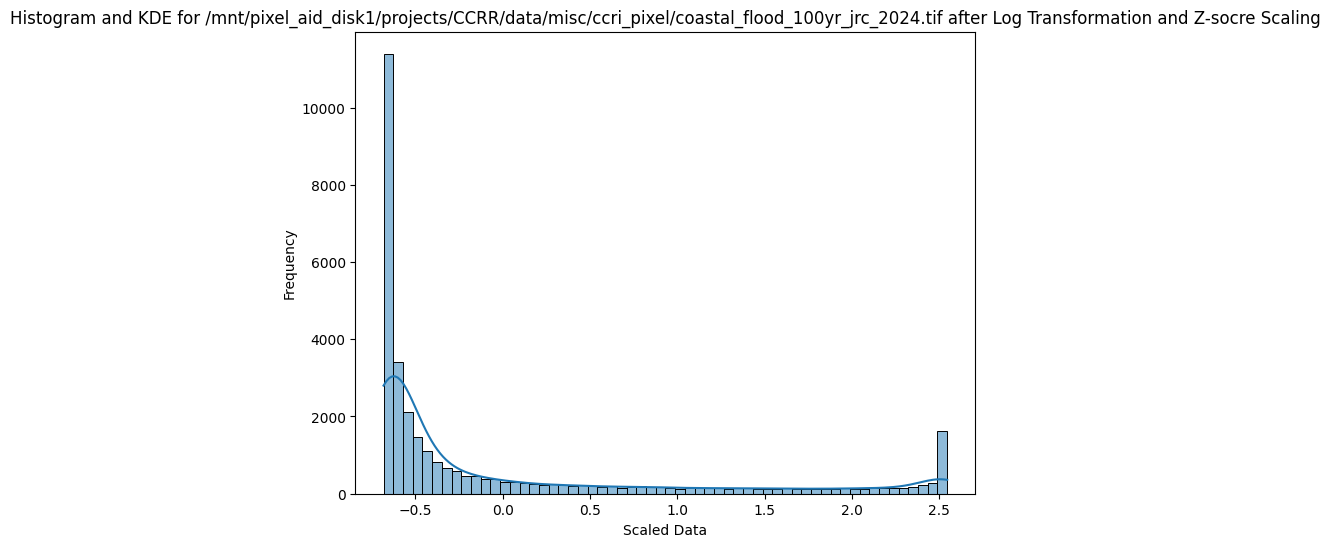

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/drought_spi_terraclimate_1958-2025.tif: Log Transformation and z-score Scaling - skew=0.913, kurtosis=0.937


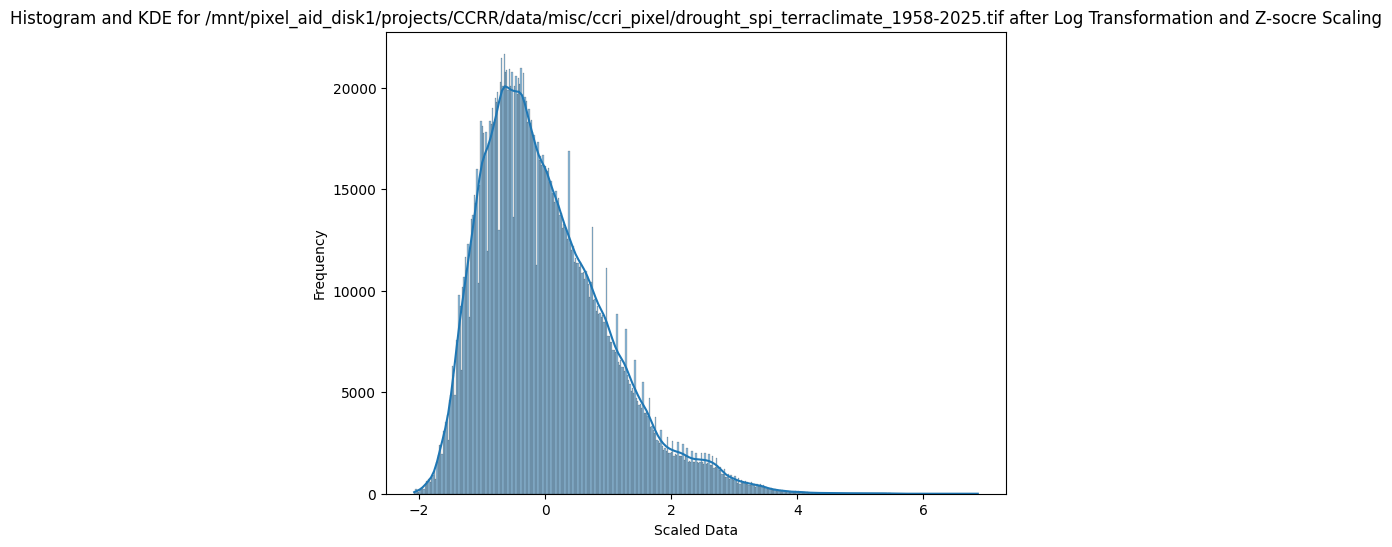

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/heatwave_severity_ecmwf_2014-2024.tif: Log Transformation and z-score Scaling - skew=-0.059, kurtosis=-0.464


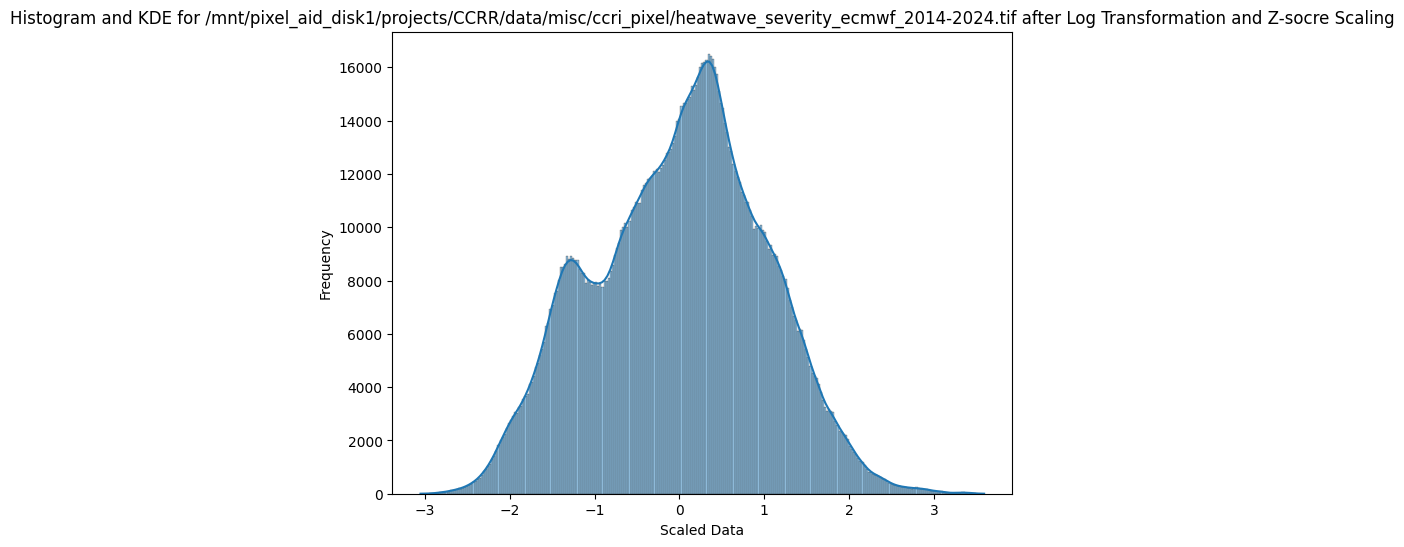

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/sand_dust_storm_unccd_2024.tif: Log Transformation and z-score Scaling - skew=-0.120, kurtosis=-0.938


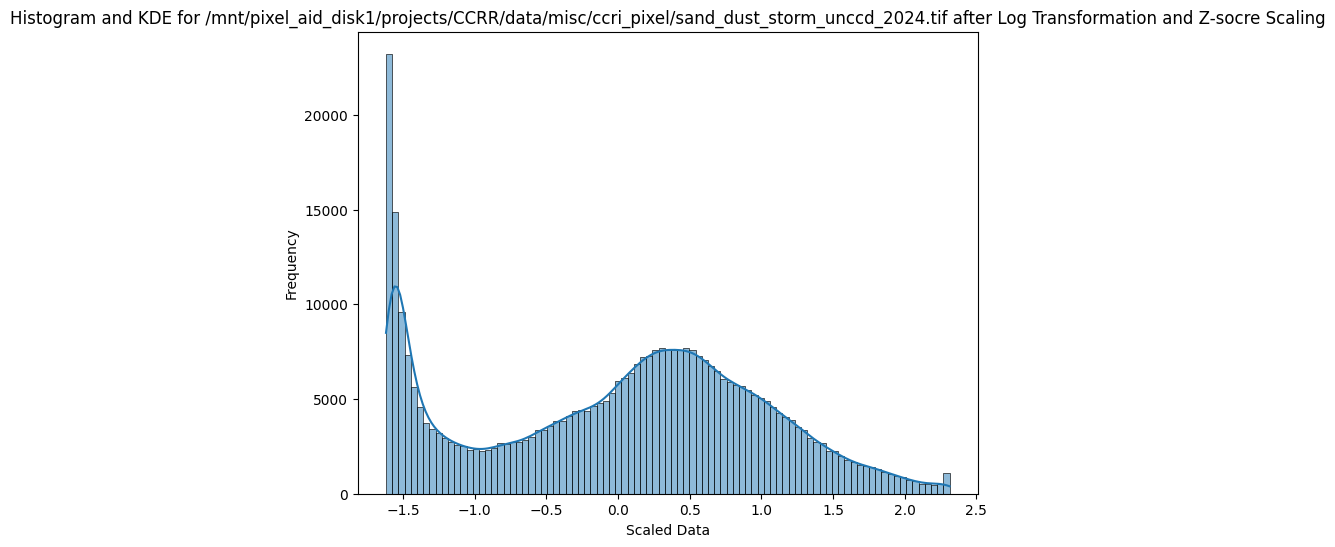

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/tropical_storm_100yr_giri_2024.tif: Log Transformation and z-score Scaling - skew=0.512, kurtosis=-0.618


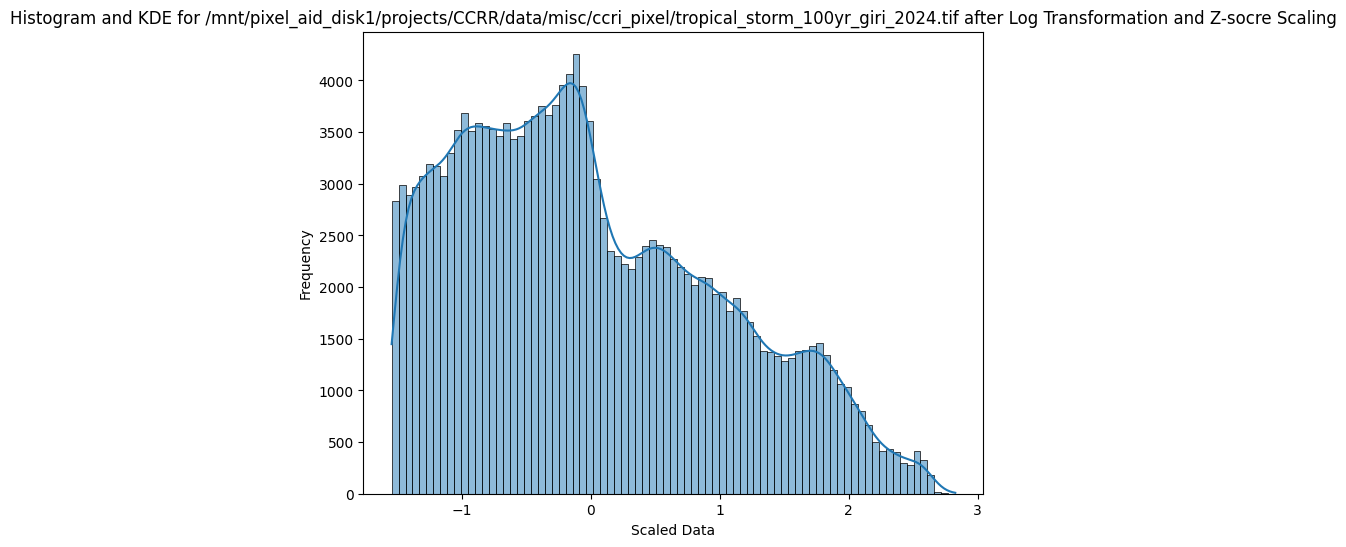

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/river_flood_100yr_jrc_2024.tif: Log Transformation and z-score Scaling - skew=0.889, kurtosis=0.628


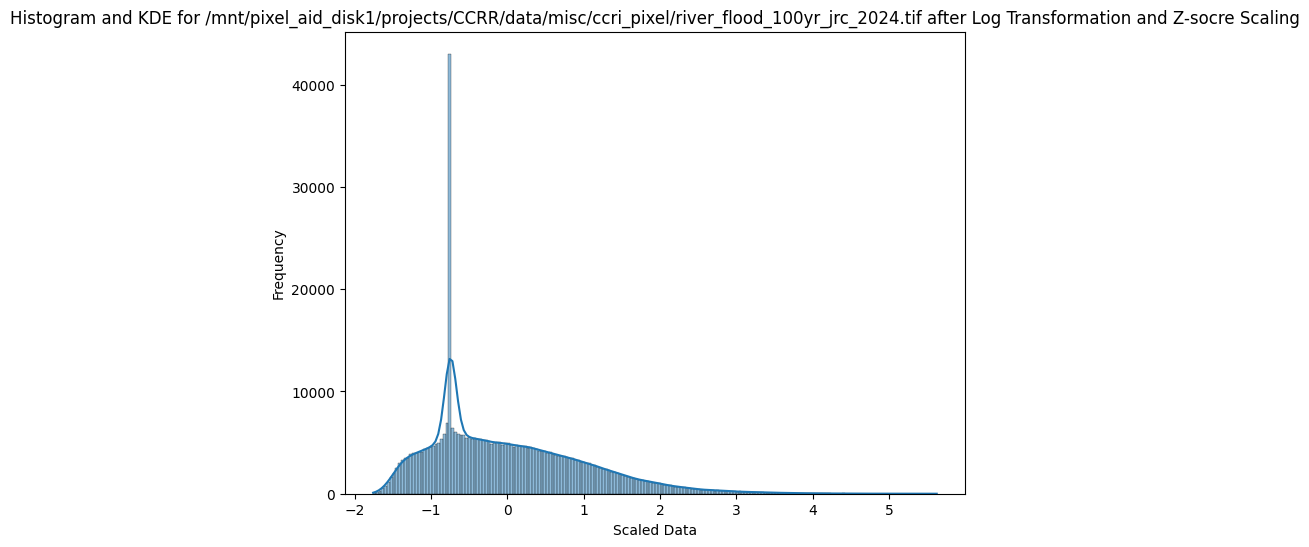

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/agricultural_drought_fao_1984-2023.tif: Log Transformation and z-score Scaling - skew=-0.439, kurtosis=-0.695


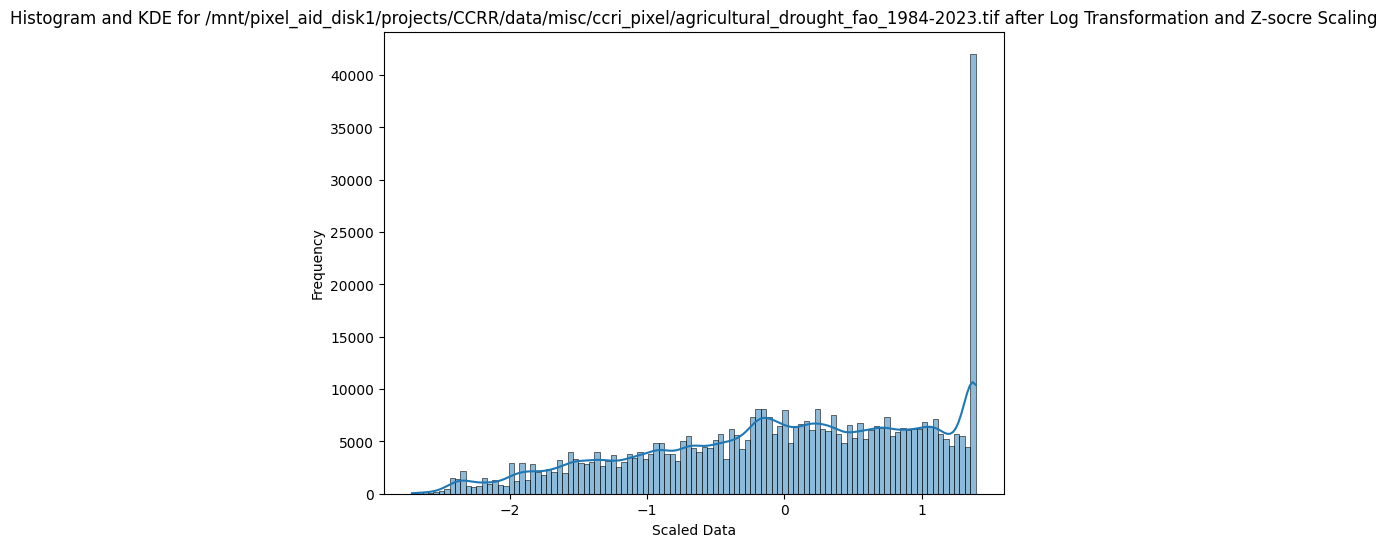

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/extreme_heat_ecmwf_2014-2024.tif: Log Transformation and z-score Scaling - skew=-0.417, kurtosis=-1.088


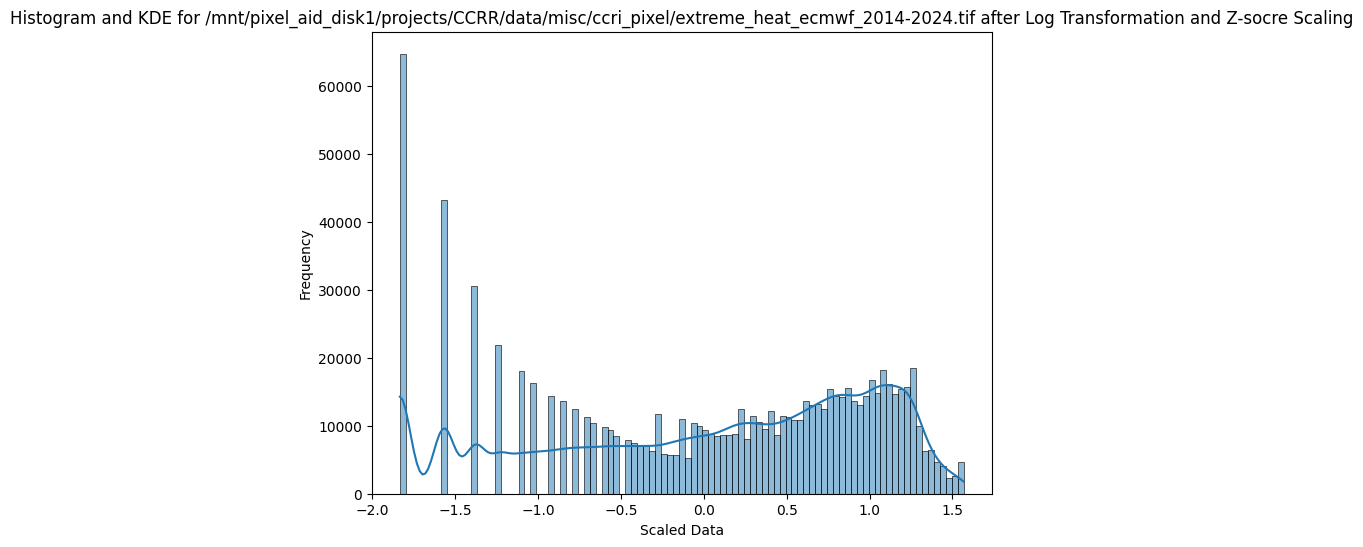

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/heatwave_duration_ecmwf_2014-2024.tif: Log Transformation and z-score Scaling - skew=0.137, kurtosis=2.040


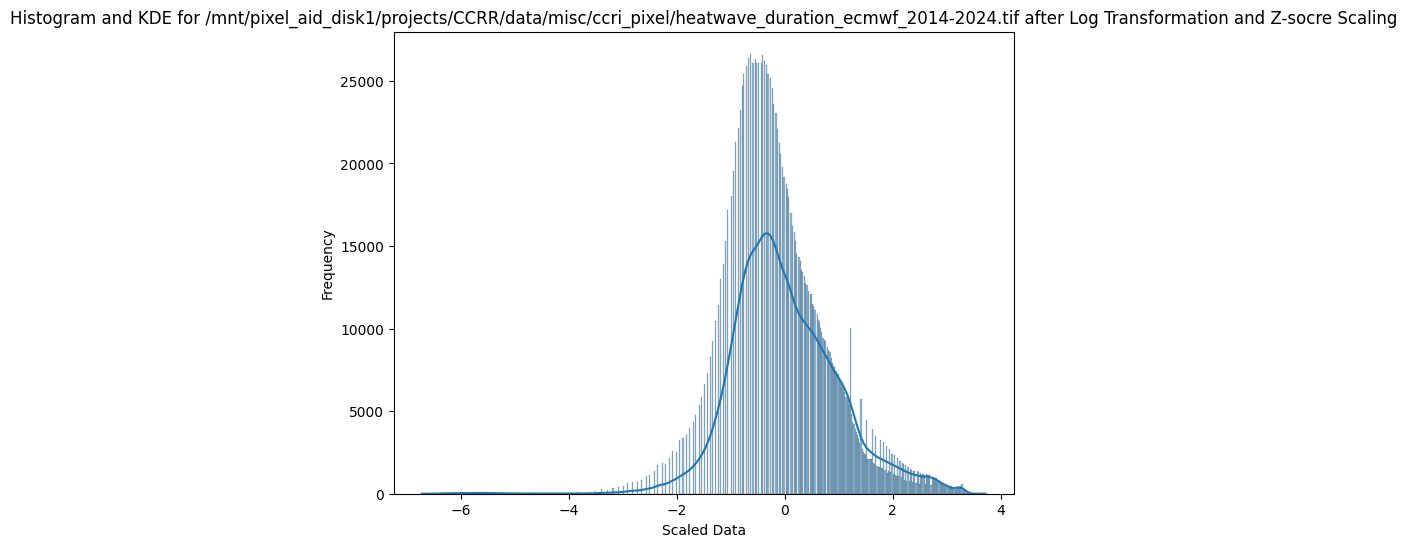

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/heatwave_frequency_ecmwf_2014-2024.tif: Log Transformation and z-score Scaling - skew=0.193, kurtosis=0.808


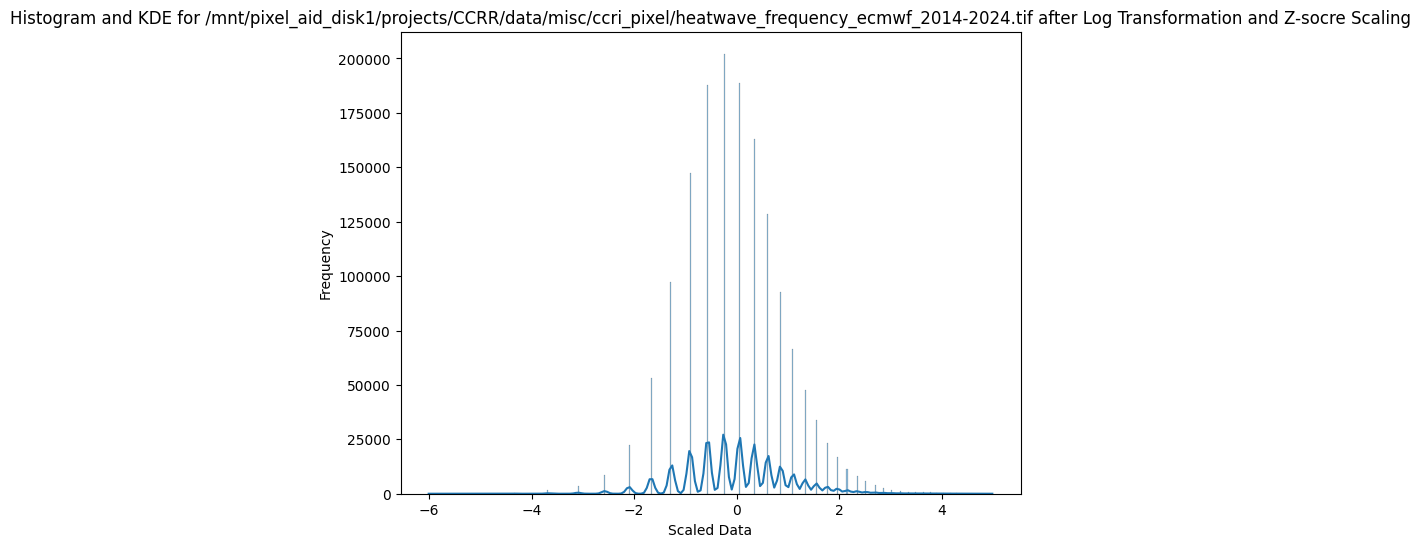

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/fire_frequency_nasa_2001-2023.tif: Log Transformation and z-score Scaling - skew=1.087, kurtosis=0.839


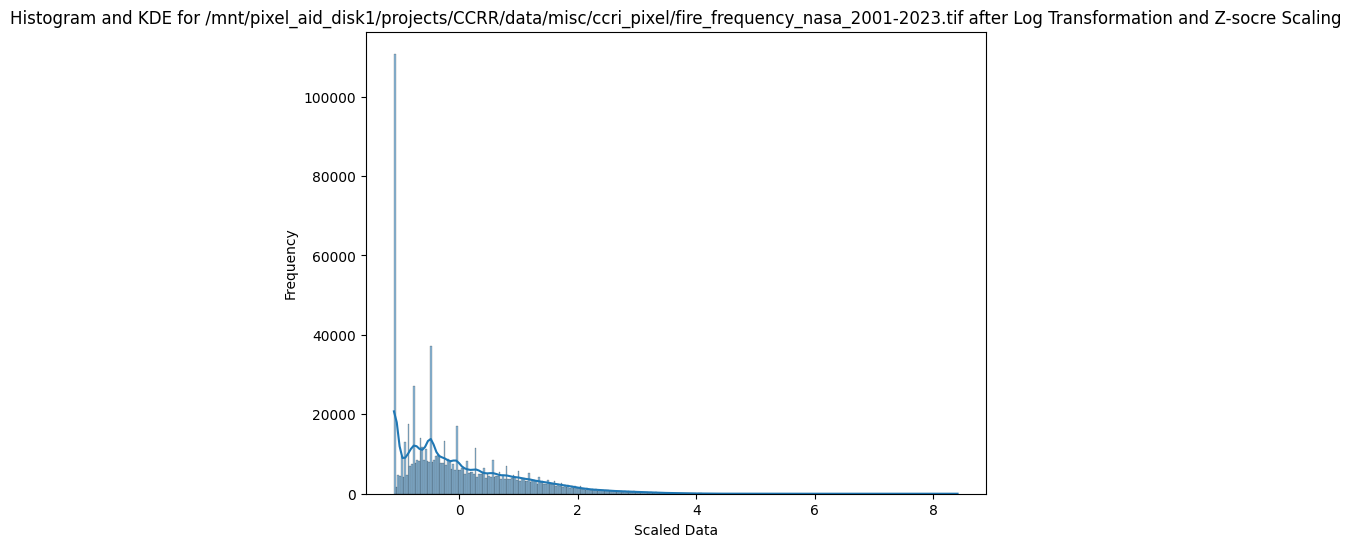

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/drought_spei_terraclimate_1958-2025.tif: Log Transformation and z-score Scaling - skew=1.194, kurtosis=2.071


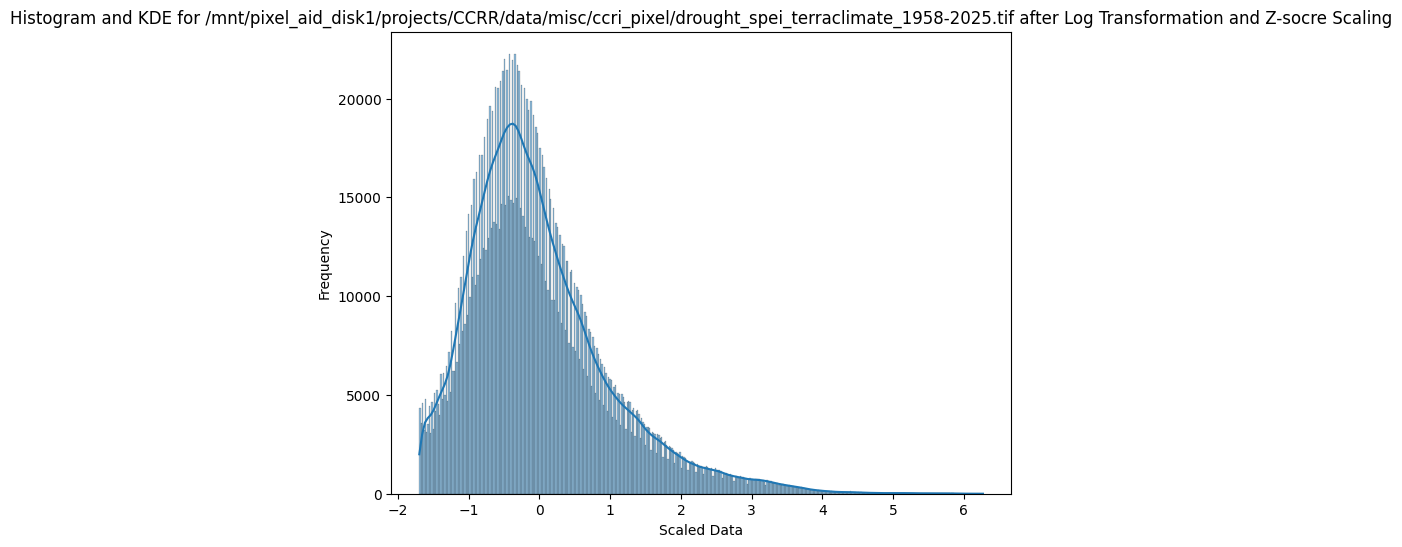

In [33]:
#plot data ditribution after log transformation and z-scor based normalization
for idx, image_file in enumerate(image_files):
    if image_file in [
                      os.path.join(image_folder,"landSeaMask.tif")
    ]:
      continue
    data = load_image(image_file)
    cleaned_data = data[~np.isnan(data)]  # Remove NaNs
    filtered_data = cleaned_data[cleaned_data > 0]  # Remove zeros and negatives

    if len(filtered_data) > 0:
        # Apply log transformation (log(1 + x) to avoid log(0))
        log_data = np.log1p(filtered_data)

        # Apply MinMax scaling to the log-transformed data
        log_data_scaled = scaler.fit_transform(log_data.reshape(-1, 1)).flatten()

        #get trimmed value
        #trimmed_values, min_trimmed, max_trimmed = trim_outliers_iteratively(log_data_scaled)

        # Check normality using D'Agostino-Pearson test
        current_skew = skew(log_data_scaled)
        current_kurtosis = kurtosis(log_data_scaled)
        print(f"{image_file}: Log Transformation and z-score Scaling - skew={current_skew:.3f}, kurtosis={current_kurtosis:.3f}")

        # Plot histogram and normality check
        plt.figure(figsize=(8, 6))
        sns.histplot(log_data_scaled, kde=True)
        plt.title(f"Histogram and KDE for {image_file} after Log Transformation and Z-socre Scaling")
        plt.xlabel("Scaled Data")
        plt.ylabel("Frequency")
        plt.show()


In [ ]:
def load_image(image_file):
    with rasterio.open(image_file) as src:
        data = src.read(1).astype(np.float32)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        data[data < -1e6] = np.nan
        return data

normalized_data = []

def log_transform_and_scale(land_pixels):
    """Takes a 1-D array of land pixel values (NaN already 0), returns z-score scaled."""
    land_pixels[land_pixels < 0] = 0
    log_data = np.log1p(land_pixels)
    log_data_scaled = StandardScaler().fit_transform(log_data.reshape(-1, 1)).flatten()
    return np.clip(log_data_scaled, -3, 3)

In [ ]:

# Load land-sea mask (in case cells are run out of order)
mask_path = os.path.join(image_folder, "landSeaMask.tif")
with rasterio.open(mask_path) as mask_src:
    landsea_mask = mask_src.read(1)
    land_mask = landsea_mask == 1

normalized_data = []

for image_file in image_files:
    if image_file == os.path.join(image_folder, "landSeaMask.tif"):
        continue
    data = load_image(image_file)
    land_pixels = data[land_mask]                           # extract land only
    land_pixels = np.nan_to_num(land_pixels, nan=0.0)      # NaN → 0
    normalized_data.append(log_transform_and_scale(land_pixels))

# land_pixels matrix: shape (n_land_pixels, n_layers)
land_pixels = np.column_stack(normalized_data)
n_layers = land_pixels.shape[1]

scaler = StandardScaler()
no_pca = 6

pca = PCA(n_components=no_pca)
land_pixels_pca = pca.fit_transform(land_pixels)
explained_variance = pca.explained_variance_ratio_.sum()
print(f"Total layers : {n_layers}")
print(f"Land pixels  : {land_mask.sum():,}")
print(f"Explained variance by {no_pca} PCA components: {explained_variance*100:.2f}%")

In [36]:
#get weights for each layers using pca loading and explaine variance by each PC
pca_loadings = pca.components_  # Shape: (n_components, n_features)
explained_var = pca.explained_variance_ratio_  # Contribution of each PC
weighted_loadings = np.dot(explained_var[:no_pca], pca_loadings[:no_pca])  # Weighted sum of top 6 PCs
indicator_weighted = np.dot(land_pixels, weighted_loadings)  # Apply weights

/mnt/pixel_aid_disk1/projects/CCRR/data/misc/ccri_pixel/drought_spei_terraclimate_1958-2025.tif: Log Transformation and z-score Scaling - skew=1.194, kurtosis=2.071


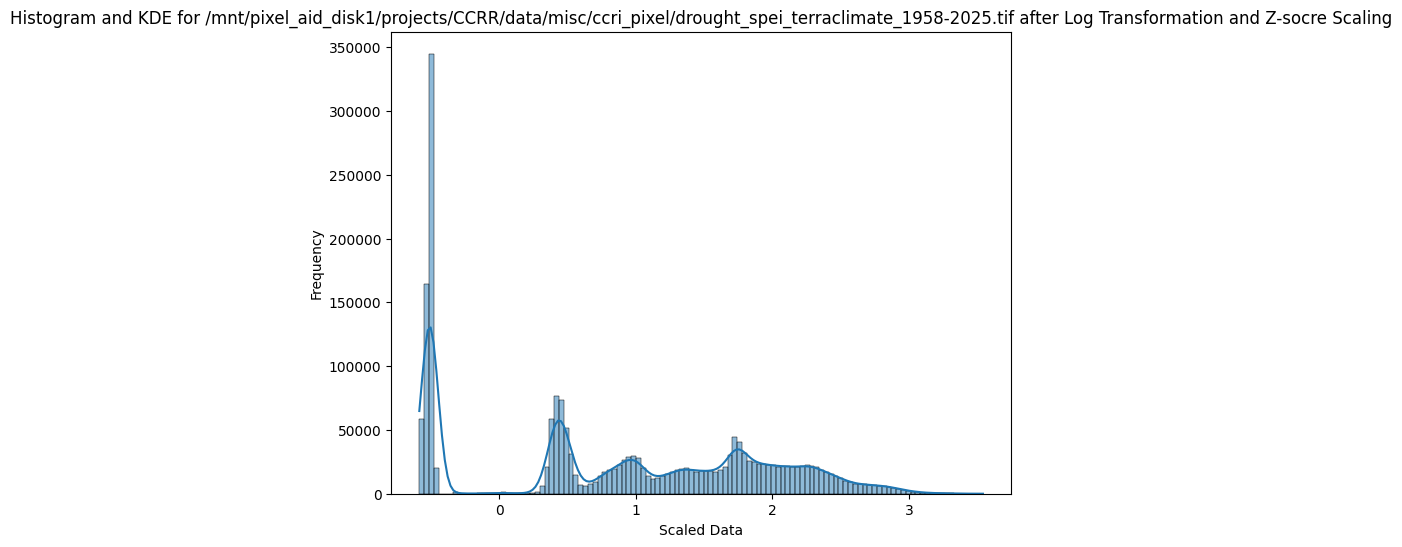

In [37]:
print(f"{image_file}: Log Transformation and z-score Scaling - skew={current_skew:.3f}, kurtosis={current_kurtosis:.3f}")

# Plot histogram and normality check
plt.figure(figsize=(8, 6))
sns.histplot(indicator_weighted, kde=True)
plt.title(f"Histogram and KDE for {image_file} after Log Transformation and Z-socre Scaling")
plt.xlabel("Scaled Data")
plt.ylabel("Frequency")
plt.show()

In [ ]:

# indicator_weighted.clip(min=1, max=3, out=indicator_weighted)

scaler = MinMaxScaler(feature_range=(0, 10))
indicator_normalized = scaler.fit_transform(indicator_weighted.reshape(-1, 1)).flatten()

# Build output raster: NaN everywhere, fill land pixels with scores
indicator_raster = np.full(land_mask.shape, np.nan)
indicator_raster[land_mask] = indicator_normalized

print(f"Land pixels scored: {land_mask.sum():,}")

p1 score at pixel level skew=0.015, kurtosis=-1.261


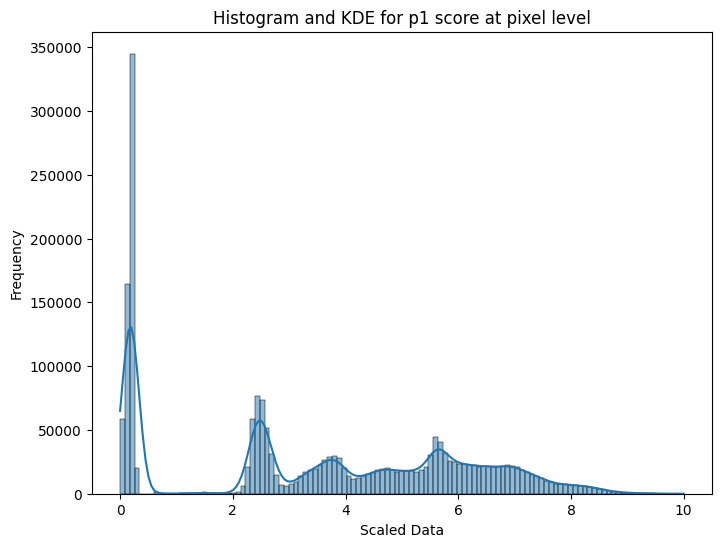

In [39]:
# Check normality using D'Agostino-Pearson test
current_skew = skew(indicator_normalized)
current_kurtosis = kurtosis(indicator_normalized)
print(f"p1 score at pixel level skew={current_skew:.3f}, kurtosis={current_kurtosis:.3f}")

# Plot histogram and normality check
plt.figure(figsize=(8, 6))
sns.histplot(indicator_normalized, kde=True)
plt.title(f"Histogram and KDE for p1 score at pixel level")
plt.xlabel("Scaled Data")
plt.ylabel("Frequency")
plt.show()

In [40]:

# Export the geometric average as a GeoTIFF
output_folder = f"{data_dir}/CCRI_results_misc"
output_path = os.path.join(output_folder, "MHI_climate.tif")

os.makedirs(output_folder, exist_ok=True)

# Use the profile from an existing image to match metadata
with rasterio.open(os.path.join(image_folder, image_files[1])) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

indicator_raster = indicator_raster.reshape(profile['height'], profile['width'])

# Write the result to a GeoTIFF
with rasterio.open(output_path, 'w', **profile) as dst:
    dst.write(indicator_raster, 1)

print(f"Risk Sum image exported to {output_path}")

Risk Sum image exported to /mnt/pixel_aid_disk1/projects/CCRR/data/CCRI_results_misc/MHI_climate.tif


                           PC1       PC2       PC3       PC4       PC5  \
fire_FRP              0.470805 -0.406661  0.044567 -0.075275 -0.338483   
coastal_flood         0.001509 -0.004893 -0.002474  0.000525  0.011716   
drought_spi          -0.088490 -0.078939 -0.147189  0.559887 -0.100389   
heatwave_severity     0.285260  0.308089 -0.471277 -0.145832  0.067952   
sand_dust             0.069117  0.495254  0.387627  0.056958 -0.113929   
tropical_storm        0.092058 -0.015213  0.117756  0.006673  0.054554   
river_flood           0.169590  0.064245 -0.076543  0.168762  0.152551   
agricultural_drought  0.325740 -0.314271  0.162754  0.095041  0.821053   
extreme_heat          0.369231  0.297045  0.566357  0.304495 -0.079026   
heatwave_duration     0.342595  0.286852 -0.268078 -0.062339  0.037734   
heatwave_frequency    0.341042  0.286613 -0.267014 -0.083401  0.043929   
fire_frequency        0.411126 -0.361826  0.024667 -0.077653 -0.376099   
drought_spei          0.044494 -0.0382

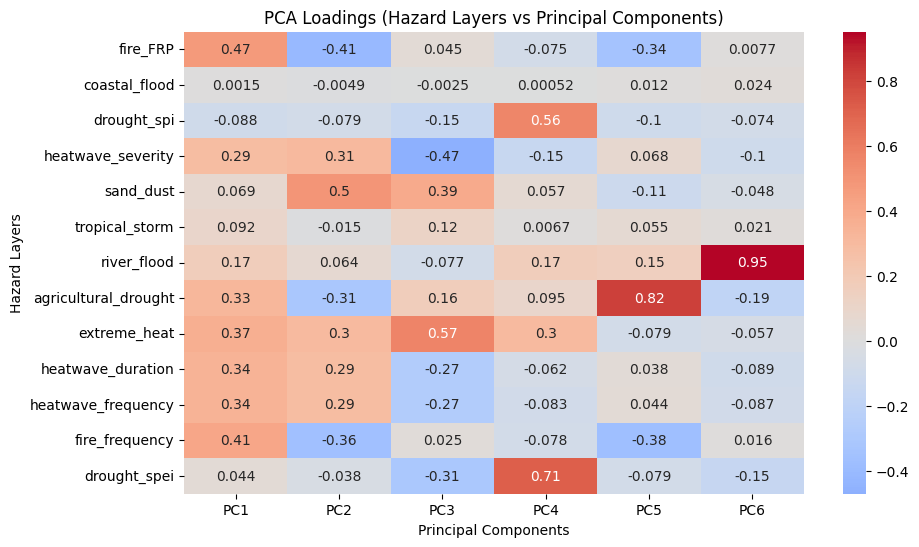

In [41]:
# Get the PCA loadings (eigenvectors)
loadings = pca.components_

# Create a DataFrame to display the relationship between hazard layers and PCs
hazard_layers = [
    '_'.join(file.split('/')[-1].split('_')[:2])
    for file in image_files
    if 'landSeaMask.tif' not in file
]
loadings_df = pd.DataFrame(loadings.T, index=hazard_layers, columns=[f'PC{i+1}' for i in range(loadings.shape[0])])

# Sort and display the most influential layers for each PC
print(loadings_df)

# Plot the heatmap showing the relationship between hazard layers and principal components
plt.figure(figsize=(10, 6))
sns.heatmap(loadings_df, annot=True, cmap="coolwarm", center=0)
plt.title("PCA Loadings (Hazard Layers vs Principal Components)")
plt.xlabel("Principal Components")
plt.ylabel("Hazard Layers")
plt.show()